# Reordering a sparse matrix with reverse Cuthill-McKee

We assemble the matrix of $-\Delta u + u$ on a general triangulation and look at its sparsity pattern before and after the reverse Cuthill-McKee (RCM) ordering.

The weak form with natural boundary conditions is

$$\int_\Omega \left(\nabla u\cdot\nabla v + u\,v\right)dx = \int_\Omega f\,v\,dx \qquad \text{for all } v,$$

so the matrix is $A_{ij} = \int_\Omega \left(\nabla\phi_j\cdot\nabla\phi_i + \phi_j\,\phi_i\right)dx$. It is symmetric positive definite, and $A_{ij} \ne 0$ only when $\phi_i$ and $\phi_j$ share a triangle.

The numbering of the unknowns does not change the matrix, only the order of its rows and columns. It does change the work of a direct solver. RCM numbers the unknowns by a breadth-first sweep across the mesh, so neighbors get nearby numbers and the entries gather in a narrow band around the diagonal.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, dx

An L-shaped domain with a circular hole, triangulated with Delaunay refinement. The vertices are numbered in the order the mesh generator created them, which has little to do with where they lie.

7143 triangles, 3736 unknowns, 25494 nonzeros


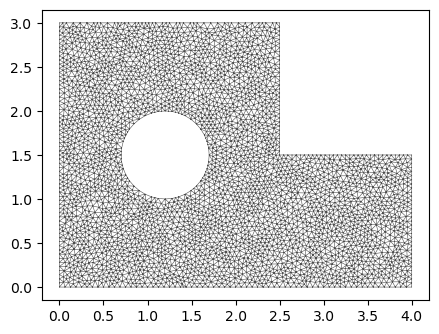

In [8]:
outer = [(0, 0), (4, 0), (4, 1.5), (2.5, 1.5), (2.5, 3), (0, 3)]
m = fd.triangulate(outer, holes=[fd.circle(1.2, 1.5, 0.5, 40)], max_edge=0.08, min_angle=28)

V = fd.LagrangeSpace(m, 1)
u, v = fd.TrialFunction(V), fd.TestFunction(V)
A = fd.form((dot(grad(u), grad(v)) + u * v) * dx).assemble()
print(m.ntriangles, "triangles,", V.dim, "unknowns,", A.nnz, "nonzeros")

fig, ax = plt.subplots(figsize=(5, 5))
m.plot(ax)
plt.show()

`A.ordering("rcm")` computes the RCM order in C++ from the pattern of $A$. `p[k]` is the unknown that becomes number $k$, and `A.permuted(p)` is the reordered matrix $P A P^T$. For comparison we also compute the approximate minimum degree (AMD) order, the one the sparse Cholesky solver uses by default. `A.bandwidth(p)` is the half-bandwidth $\max \lvert i - j\rvert$ over the nonzeros in the order `p`.

In [9]:
p_rcm = A.ordering("rcm")
p_amd = A.ordering("amd")
A_rcm = A.permuted(p_rcm)
A_amd = A.permuted(p_amd)

print("half-bandwidth, natural order:", A.bandwidth())
print("half-bandwidth, RCM order:    ", A.bandwidth(p_rcm))

half-bandwidth, natural order: 3705
half-bandwidth, RCM order:     81


**The sparsity patterns.** Both matrices have the same number of nonzeros. In the natural order they are spread over the whole matrix, while RCM gathers them in a band.

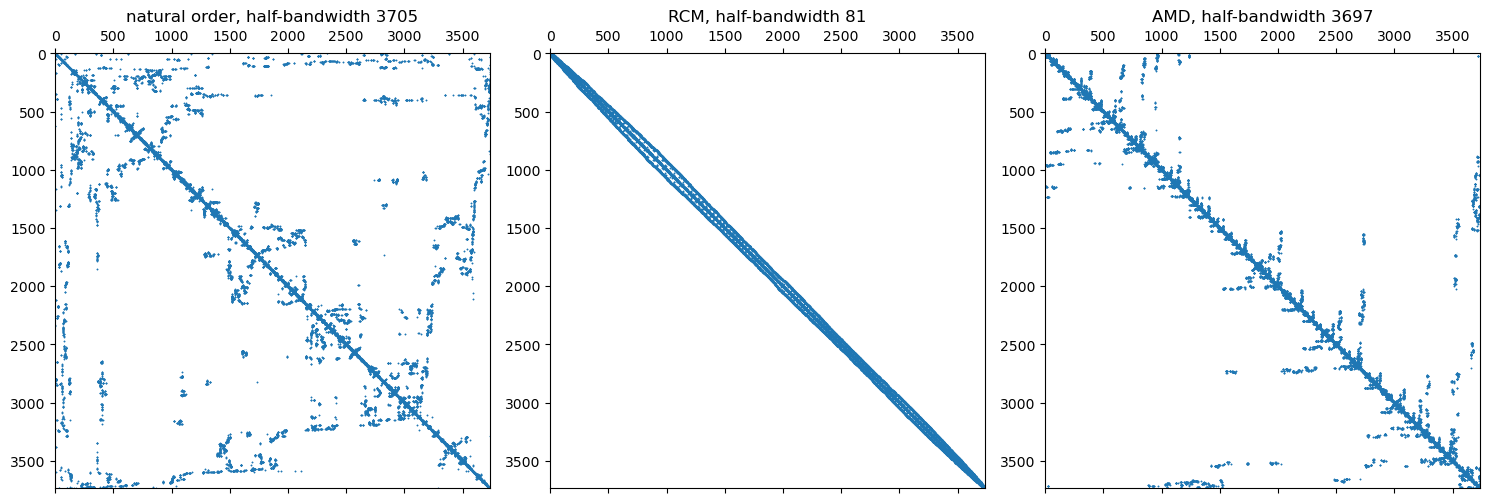

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, M, title in zip(axs, (A, A_rcm, A_amd), ("natural order", "RCM", "AMD")):
    ax.spy(M.tocsr(), markersize=0.4)
    ax.set_title(f"{title}, half-bandwidth {M.bandwidth()}")
plt.tight_layout()
plt.show()

**The numbering on the mesh.** Coloring each vertex by its number shows what RCM does. It starts at a vertex at the edge of the domain and sweeps across it in level sets, like a front moving through the mesh. The natural numbering has no such structure.

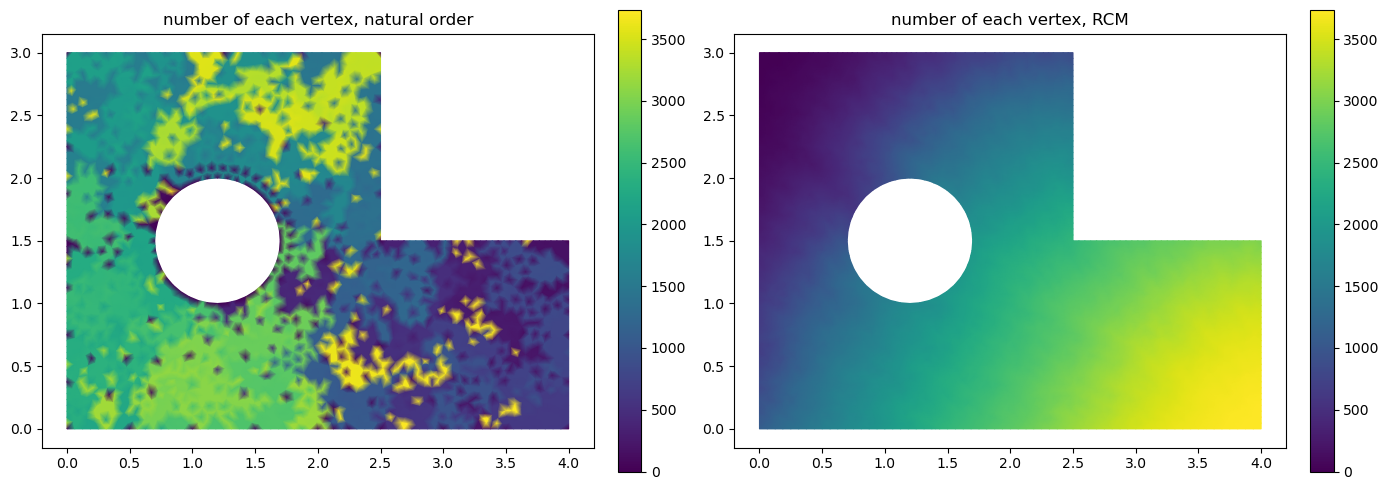

In [11]:
def numbering(p):
    rank = np.empty(V.dim)
    rank[p] = np.arange(V.dim)                      # rank[i] is the new number of unknown i
    return fd.Function(V, "number", rank)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for ax, p, title in zip(axs, (np.arange(V.dim), p_rcm), ("natural order", "RCM")):
    numbering(p).plot(ax, cmap="viridis")
    ax.set_title(f"number of each vertex, {title}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**What it means for a direct solver.** The Cholesky factor $L$ of $P A P^T$ fills in, and the fill depends on the order. A banded matrix keeps all of its fill inside the band, so RCM bounds it by $n$ times the half-bandwidth. AMD does not aim for a band at all. Its pattern looks scattered, but it chooses each pivot to create as little fill as possible, and it usually gives the sparsest factor. We factor the natural and RCM matrices without further reordering, and $A$ with AMD.

In [12]:
print("order     nonzeros of L     flops")
for name, M, ordering in (("natural", A, "natural"), ("RCM", A_rcm, "natural"), ("AMD", A, "amd")):
    L = M.solver("cholesky", ordering=ordering).factor
    print(f"{name:8s} {L.nnz_L:12d} {L.flops:12.3g}")

order     nonzeros of L     flops
natural        685051     2.52e+08
RCM            169350     8.54e+06
AMD             59042     1.73e+06


RCM makes the factor about four times sparser than the natural order, and the factorization about thirty times cheaper. AMD does better still, which is why it is the default. RCM remains the better choice where a band is what matters, for a banded solver or for preconditioners such as ILU(0) and SSOR, whose quality depends on the order of the unknowns. FEMd builds those on the RCM order by default.